In [21]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'model' and 'networks' (current directory structure)
d = current_dir
for _ in range(5):
    if (d / "model").exists() and (d / "networks").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing

In this notebook we test that the main files work well.

## Setup

In [22]:
from utils.imports import *
from model.agents import BetaAgent, BayesAgent
from model.vectorized_model import VectorizedModel


In [23]:
# n_agents = 100
# my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [24]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


## Try with Bayes Agent

In [25]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True, sampling_update=True,
                 seed=seed, seeded=False, agent_type='bayes',
                 snapshot_interval=1000)
my_model.run_simulation(number_of_steps=100000, show_bar=True)
print('steps: ', my_model.n_steps)
print('conclusion: ', my_model.conclusion)
print('conclusion core', my_model.conclusion_core)
# df = pd.DataFrame(my_model.credences_history)
# df.head(3)


100%|██████████| 100000/100000 [00:30<00:00, 3284.12it/s]

steps:  100000
conclusion:  0.7586206896551724
conclusion core 0.8974358974358975


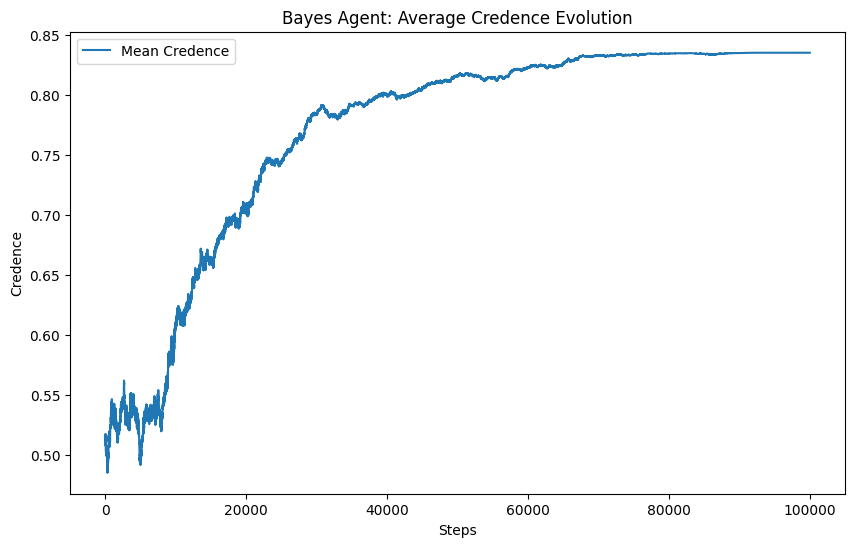

In [26]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()


## Try with Beta Agent

In [27]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True, sampling_update=True,
                 seed=seed, seeded=False, agent_type='beta',
                 tolerance_stopping=False, tstep_stopping=True,
                 snapshot_interval=1000)

my_model.run_simulation(number_of_steps=100000, show_bar=True)
print('steps: ', my_model.n_steps)
print('conclusion: ', my_model.conclusion)
df = pd.DataFrame(my_model.credences_history)
df.head(3)


100%|██████████| 100000/100000 [00:41<00:00, 2416.06it/s]


steps:  100000
conclusion:  0.8045977011494253


,0,1,2,3,4,5,6,7,8,9,...,99991,99992,99993,99994,99995,99996,99997,99998,99999,100000
0,"[0.6280307179233172, 0.5681410227493051]","[0.5158389068296755, 0.7791663566878864]","[0.33089974629848795, 0.6713823160330551]","[0.3738539974507865, 0.5548424422925223]","[0.4947590827033818, 0.6313832936793425]","[0.5247501411939828, 0.53429923954536]","[0.29065216014404666, 0.6172672990438391]","[0.3888854571805942, 0.5354803879533352]","[0.34901678185335927, 0.4865855292770233]","[0.36333098126298696, 0.5528477284931939]",...,"[0.5012880193126922, 0.5005016113087898]","[0.5001742251249667, 0.5011248728310723]","[0.5000999197283637, 0.5002447661916107]","[0.5008933872555247, 0.5006871872347316]","[0.499755979810369, 0.5007954369613341]","[0.5004087663323519, 0.5008223621300717]","[0.4991985826385795, 0.500745266447478]","[0.5011818713720351, 0.5008315181259491]","[0.49957261730239594, 0.5003041944876244]","[0.5009184452906899, 0.5009359477528662]"
1,"[0.0004989878182686837, 0.768832451698921]","[0.2994615401548671, 0.6153258292915271]","[0.4965870453090197, 0.3458606193178146]","[0.647714905123439, 0.3850430739291993]","[0.5297613934860582, 0.47453286309173104]","[0.5694861614201329, 0.36742454270345964]","[0.5966879573451888, 0.5137837149461043]","[0.6204645012227836, 0.34959060209998666]","[0.5810183964077433, 0.4950767373897468]","[0.568973693277101, 0.31734493231771316]",...,"[0.5003008270913587, 0.5007802075362693]","[0.4993470376734928, 0.5004697220376346]","[0.498595790846469, 0.5007069212942687]","[0.5002773682279437, 0.5013537006577747]","[0.49928367346952135, 0.5016094664987766]","[0.4998592992028867, 0.5003218122401122]","[0.5000953746971278, 0.5002485392459604]","[0.5004442144644868, 0.5011810130158099]","[0.5008309910927253, 0.5014804045136841]","[0.4999341122867496, 0.5011746332608409]"
2,"[0.4722407562886363, 0.38947229347297824]","[0.45620013231333095, 0.3829797325946501]","[0.626365537459526, 0.4175666780045334]","[0.442398758983268, 0.28819489444259894]","[0.5064664591021203, 0.3949843666269247]","[0.47906503830228525, 0.5803224882456959]","[0.5063065540017282, 0.4416321569674898]","[0.5271271038448428, 0.395510224388849]","[0.4566786253060323, 0.4955780466333803]","[0.48338098430500565, 0.4691647863126368]",...,"[0.49995859618360106, 0.501140624435366]","[0.5002798581662643, 0.5010399161822293]","[0.49898365598162875, 0.5012563129863125]","[0.5002481432090508, 0.5010043950758201]","[0.5005832188647557, 0.5014098220542588]","[0.4993346873085033, 0.5010787764592657]","[0.5000058676793103, 0.5007211887938485]","[0.5002792571474016, 0.5011666789634228]","[0.5011198935722574, 0.5011687027681627]","[0.5006864187310489, 0.5008660451032418]"


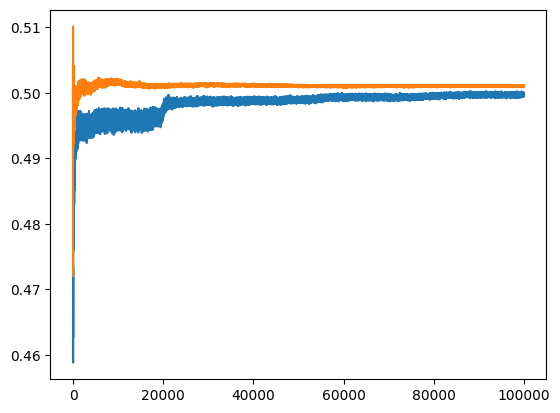

In [28]:
#Extract the first coordinate (x) for each pair and calculate column-wise mean
x_means = df.map(lambda pair: pair[0]).mean()
y_means = df.map(lambda pair: pair[1]).mean()
plt.plot(x_means)
plt.plot(y_means)

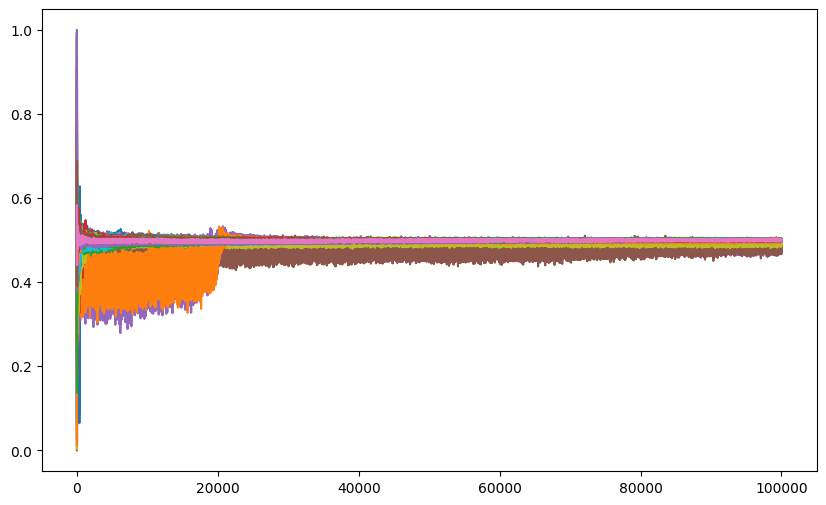

In [29]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row
plt.figure(figsize=(10, 6))
for row_idx in range(x_values.shape[0]):
    plt.plot(x_values.columns, x_values.iloc[row_idx, :], label=f'Row {row_idx+1}' if row_idx < 5 else None)

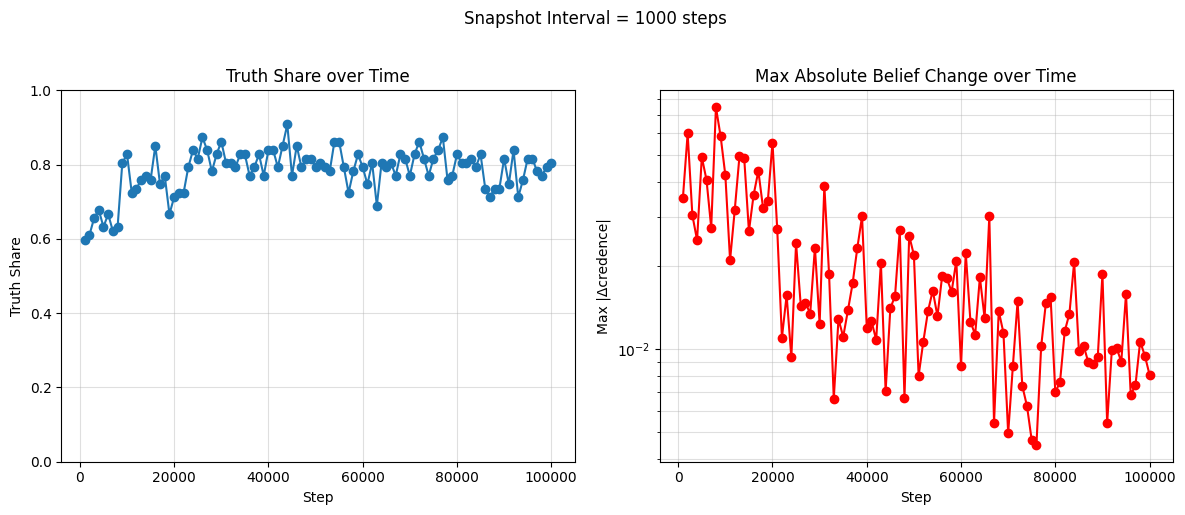

In [30]:
# ── Snapshot Trajectories ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

snapshots = my_model.snapshots

if snapshots and len(snapshots['step']) > 0:
    steps             = snapshots['step']
    truth_shares      = snapshots['truth_share']
    max_belief_changes = snapshots['max_belief_change']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(steps, truth_shares, marker='o', linestyle='-')
    axes[0].set_title('Truth Share over Time')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Truth Share')
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.4)

    # Filter out None values from bayes agents
    valid_changes = [(s, c) for s, c in zip(steps, max_belief_changes) if c is not None]
    if valid_changes:
        s_vals, c_vals = zip(*valid_changes)
        axes[1].plot(s_vals, c_vals, marker='o', linestyle='-', color='red')
        axes[1].set_title('Max Absolute Belief Change over Time')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Max |Δcredence|')
        axes[1].set_yscale('log')
        axes[1].grid(True, alpha=0.4, which='both')
    else:
        axes[1].set_visible(False)

    plt.suptitle(f'Snapshot Interval = {my_model.snapshot_interval} steps', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No snapshots recorded. Run with snapshot_interval > 0.')
